<a href="https://colab.research.google.com/github/gabcsx/CCDATSCL_EXERCISES_COM221ML/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [162]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [163]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [165]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [166]:
df.query("`Country/Region` == 'Philippines'")

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
47943,NaN,Philippines,12.879721,121.774017,2020-07-23,74390,1871,24383,48136,Western Pacific
48204,NaN,Philippines,12.879721,121.774017,2020-07-24,76444,1879,24502,50063,Western Pacific
48465,NaN,Philippines,12.879721,121.774017,2020-07-25,78412,1897,25752,50763,Western Pacific
48726,NaN,Philippines,12.879721,121.774017,2020-07-26,80448,1932,26110,52406,Western Pacific


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

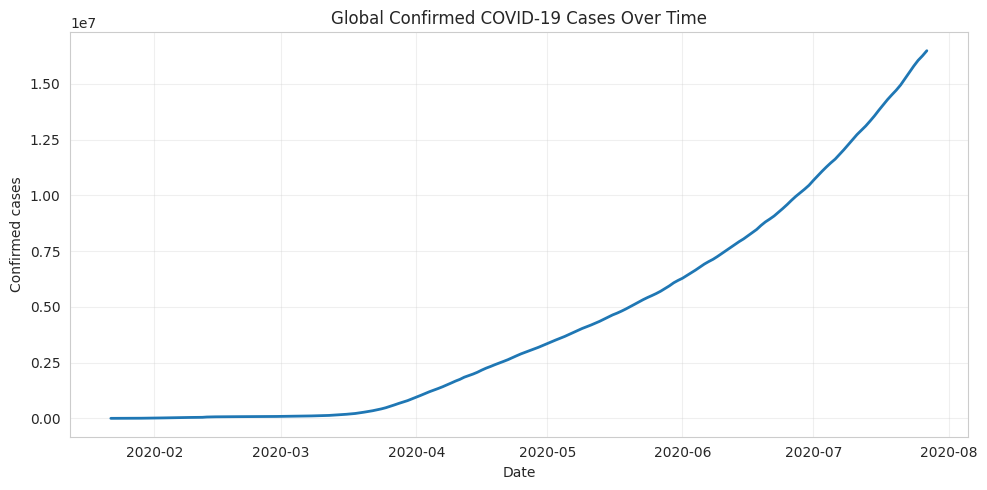

In [167]:
import matplotlib.pyplot as plt
import pandas as pd

df_time = df.copy()

# Convert Date column to datetime
df_time["Date"] = pd.to_datetime(df_time["Date"], errors="coerce")

# Remove rows with invalid dates
df_time = df_time.dropna(subset=["Date"])

# If we have multiple rows per date (e.g., per country/province), sum to global
confirmed_by_date = (
    df_time.groupby("Date", as_index=False)["Confirmed"].sum().sort_values("Date")
)

# Plot global confirmed cases over time
plt.figure(figsize=(10, 5))
plt.plot(confirmed_by_date["Date"], confirmed_by_date["Confirmed"], linewidth=2)
plt.title("Global Confirmed COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

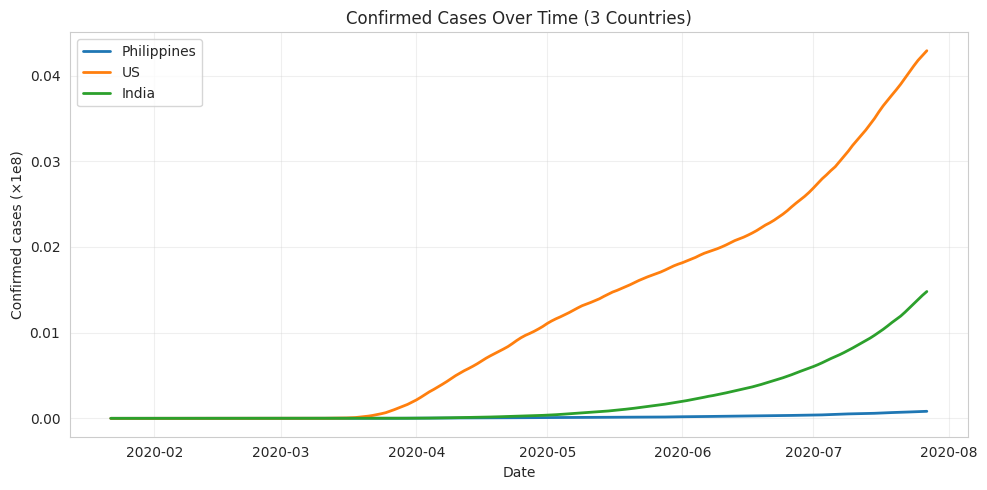

In [174]:
import matplotlib.ticker as mtick

# Select 3 countries to compare
countries = ["Philippines", "US", "India"]

# Filter for selected countries
df_countries = df[df["Country/Region"].isin(countries)].copy()

# Group by Date and Country/Region and sum Confirmed
country_ts = (
    df_countries.groupby(["Date", "Country/Region"], as_index=False)["Confirmed"].sum()
    .sort_values(["Country/Region", "Date"])
)

# Create scaled confirmed values to 1e8
country_ts["Confirmed_1e8"] = country_ts["Confirmed"] / 1e8

# Plot confirmed cases for each country (scaled)
plt.figure(figsize=(10, 5))
ax = plt.gca()
for c in countries:
    tmp = country_ts[country_ts["Country/Region"] == c]
    ax.plot(tmp["Date"], tmp["Confirmed_1e8"], linewidth=2, label=c)

# Add title and labels
ax.set_title("Confirmed Cases Over Time (3 Countries)")
ax.set_xlabel("Date")
ax.set_ylabel("Confirmed cases (×1e8)")

# Add grid, decimal ticks, and legend
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.legend()

plt.tight_layout()
plt.show()

3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

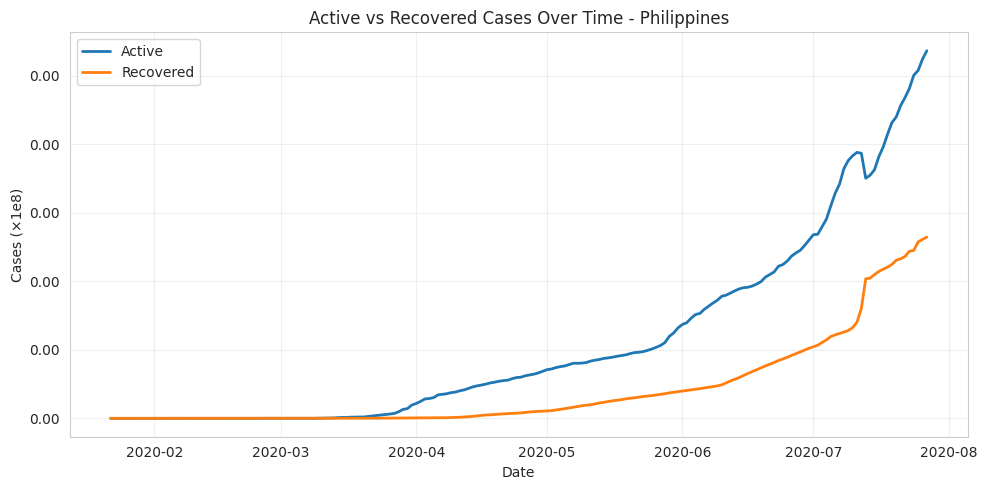

In [175]:
# Choose one country
country = "Philippines"

# Filter data for the chosen country
df_one = df[df["Country/Region"] == country].copy()

# Group by Date and sum Active and Recovered
country_ar = (
    df_one.groupby("Date", as_index=False)[["Active", "Recovered"]].sum()
    .sort_values("Date")
)

# Scale Active and Recovered to 1e8
country_ar["Active_1e8"] = country_ar["Active"] / 1e8
country_ar["Recovered_1e8"] = country_ar["Recovered"] / 1e8

# Plot Active vs Recovered (scaled)
plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.plot(country_ar["Date"], country_ar["Active_1e8"], label="Active", linewidth=2)
ax.plot(country_ar["Date"], country_ar["Recovered_1e8"], label="Recovered", linewidth=2)

# Add title and labels
ax.set_title(f"Active vs Recovered Cases Over Time - {country}")
ax.set_xlabel("Date")
ax.set_ylabel("Cases (×1e8)")

# Add grid, decimal ticks, and legend
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.legend()

plt.tight_layout()
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

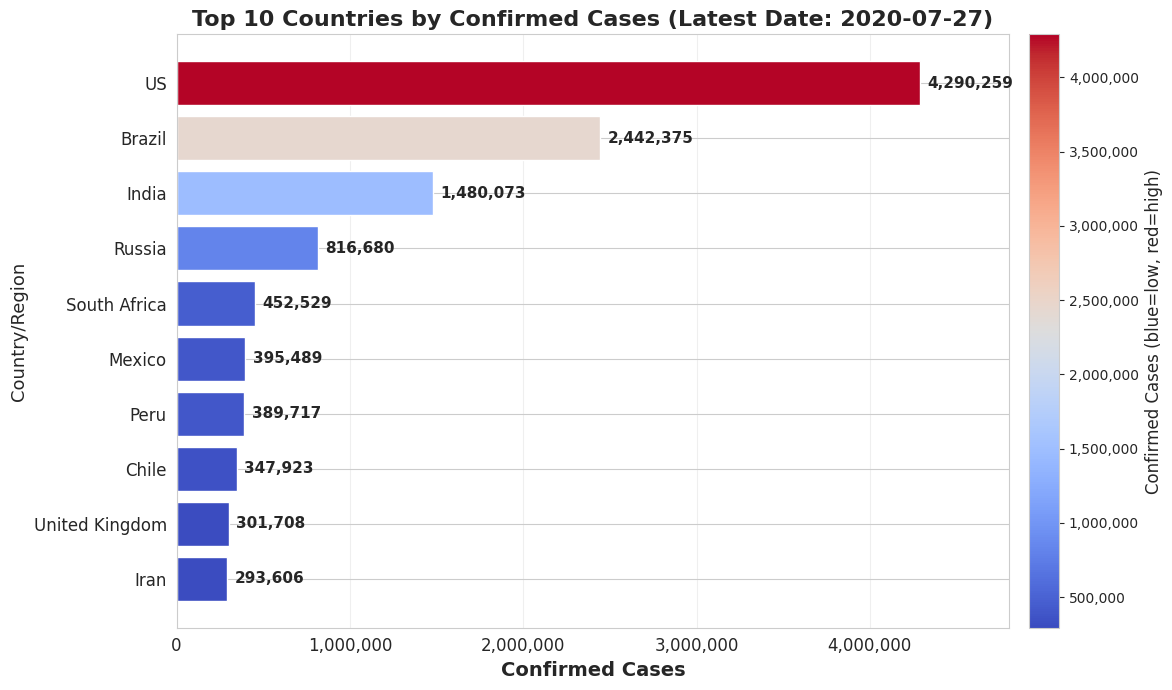

In [176]:
import matplotlib as mpl
from matplotlib.ticker import StrMethodFormatter, MaxNLocator

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Select latest date
latest_date = df["Date"].max()
latest = df[df["Date"] == latest_date]

# Top 10 countries by confirmed (sum across provinces/states)
top_confirmed = (
    latest.groupby("Country/Region", as_index=False)["Confirmed"].sum()
    .sort_values("Confirmed", ascending=False)
    .head(10)
    .sort_values("Confirmed", ascending=True)
)

# Color mapping: blue (low) -> red (high)
vals = top_confirmed["Confirmed"].to_numpy()
norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
cmap = mpl.colormaps["coolwarm"]
colors = cmap(norm(vals))

# Plot
plt.figure(figsize=(12, 7))
ax = plt.gca()

bars = ax.barh(
    top_confirmed["Country/Region"],
    top_confirmed["Confirmed"],
    color=colors
)

ax.set_title(
    f"Top 10 Countries by Confirmed Cases (Latest Date: {latest_date.date()})",
    fontsize=16, fontweight="bold"
)
ax.set_xlabel("Confirmed Cases", fontsize=14, fontweight="bold")
ax.set_ylabel("Country/Region", fontsize=13)

ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.grid(True, axis="x", alpha=0.3)

max_val = vals.max()
offset = max_val * 0.01

for bar in bars:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        w + offset, y,
        f"{w:,.0f}",
        va="center", ha="left",
        fontsize=11, fontweight="bold"
    )

ax.set_xlim(0, max_val * 1.12)

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Confirmed Cases (blue=low, red=high)", fontsize=12)

cbar.formatter = StrMethodFormatter("{x:,.0f}")
cbar.update_ticks()

plt.tight_layout()
plt.show()


5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

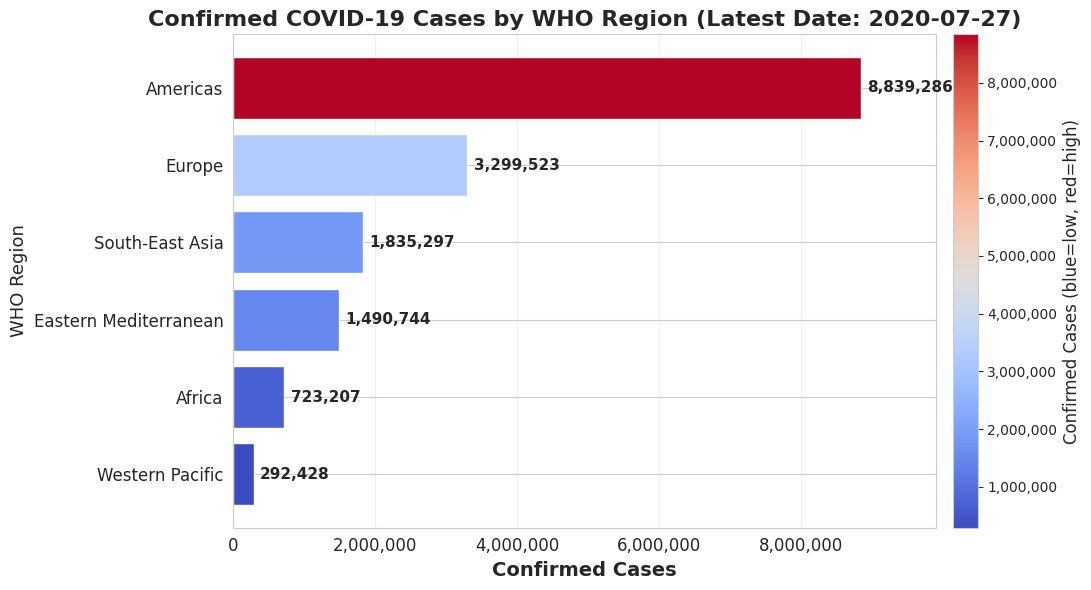

In [177]:
# Aggregate confirmed cases by WHO Region
who_summary = (
    latest.groupby("WHO Region", as_index=False)["Confirmed"]
    .sum()
    .sort_values("Confirmed", ascending=True)  # nice for barh
)

vals = who_summary["Confirmed"].to_numpy()
norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
cmap = mpl.colormaps["coolwarm"]
colors = cmap(norm(vals))

# Plot
plt.figure(figsize=(11, 6))
ax = plt.gca()

bars = ax.barh(
    who_summary["WHO Region"],
    who_summary["Confirmed"],
    color=colors
)

ax.set_title(
    f"Confirmed COVID-19 Cases by WHO Region (Latest Date: {latest_date.date()})",
    fontsize=16, fontweight="bold"
)
ax.set_xlabel("Confirmed Cases", fontsize=14, fontweight="bold")
ax.set_ylabel("WHO Region", fontsize=13)

ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.grid(True, axis="x", alpha=0.3)

max_val = vals.max()
offset = max_val * 0.01

for bar in bars:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        w + offset, y,
        f"{w:,.0f}",
        va="center", ha="left",
        fontsize=11, fontweight="bold"
    )

ax.set_xlim(0, max_val * 1.12)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Confirmed Cases (blue=low, red=high)", fontsize=12)
cbar.formatter = StrMethodFormatter("{x:,.0f}")
cbar.update_ticks()

plt.tight_layout()
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [178]:
# --- Ensure Date is datetime ---
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

lat_candidates = ["Lat", "Latitude", "lat"]
lon_candidates = ["Long", "Long_", "Longitude", "lon", "Lng", "Longitute"]

lat_col = next((c for c in lat_candidates if c in df.columns), None)
lon_col = next((c for c in lon_candidates if c in df.columns), None)

if lat_col is None or lon_col is None:
    raise ValueError(
        f"Latitude/Longitude columns not found. "
        f"Looked for lat in {lat_candidates} and lon in {lon_candidates}. "
        f"Available columns: {list(df.columns)}"
    )

# --- Required columns check ---
for c in ["Date", "Confirmed", "Country/Region"]:
    if c not in df.columns:
        raise ValueError(f"Expected column '{c}' not found. Available columns: {list(df.columns)}")

# --- Clean data ---
df_geo = df.dropna(subset=["Date", "Confirmed", "Country/Region", lat_col, lon_col]).copy()

# --- Pick a date (latest by default) ---
selected_date = df_geo["Date"].max()
# If you need a specific date instead, use:
selected_date = pd.to_datetime("2020-07-27")

snapshot = df_geo[df_geo["Date"] == selected_date].copy()

geo_snapshot = (
    snapshot.groupby("Country/Region", as_index=False)
    .agg(
        Confirmed=("Confirmed", "sum"),
        **{lat_col: (lat_col, "mean"), lon_col: (lon_col, "mean")}
    )
)

geo_snapshot["Confirmed_size"] = (
    geo_snapshot["Confirmed"]
    .clip(lower=1)
    .astype(float)
    .map(lambda x: __import__("math").log10(x))
)

# --- Plot map ---
fig = px.scatter_geo(
    geo_snapshot,
    lat=lat_col,
    lon=lon_col,
    size="Confirmed_size",
    hover_name="Country/Region",
    hover_data={"Confirmed": ":,", "Confirmed_size": False},
    projection="natural earth",
    title=f"Geographic Spread of Confirmed Cases on {selected_date.date()}",
)

fig.update_traces(marker=dict(opacity=0.65, line=dict(width=0.25, color="white")))
fig.update_layout(margin=dict(l=10, r=10, t=60, b=10))

fig.show()

7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [179]:
import plotly.express as px

# --- Ensure Date is datetime ---
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

lat_candidates = ["Lat", "Latitude", "lat"]
lon_candidates = ["Long", "Long_", "Longitude", "lon", "Lng", "Longitute"]

lat_col = next((c for c in lat_candidates if c in df.columns), None)
lon_col = next((c for c in lon_candidates if c in df.columns), None)

if lat_col is None or lon_col is None:
    raise ValueError(
        f"Latitude/Longitude columns not found. "
        f"Looked for lat in {lat_candidates} and lon in {lon_candidates}. "
        f"Available columns: {list(df.columns)}"
    )

# --- Required columns check ---
needed = ["Date", "Confirmed", "Country/Region", "WHO Region", lat_col, lon_col]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

# --- Clean ---
df_rc = df.dropna(subset=["Date", "Confirmed", "Country/Region", "WHO Region", lat_col, lon_col]).copy()

# --- Select date (latest by default) ---
selected_date = df_rc["Date"].max()
# If you need a specific date:
# selected_date = pd.to_datetime("2020-07-27")

snapshot = df_rc[df_rc["Date"] == selected_date].copy()

# --- Select ONE WHO Region ---
region = "South-East Asia"

region_rows = snapshot[snapshot["WHO Region"] == region].copy()
if region_rows.empty:
    raise ValueError(
        f"No data for WHO Region='{region}' on {selected_date.date()}. "
        f"Available regions on that date: {sorted(snapshot['WHO Region'].dropna().unique())}"
    )

region_country = (
    region_rows.groupby(["Country/Region", "WHO Region"], as_index=False)
    .agg(
        Confirmed=("Confirmed", "sum"),
        **{lat_col: (lat_col, "mean"), lon_col: (lon_col, "mean")}
    )
)

region_country["Confirmed_size"] = (
    region_country["Confirmed"]
    .clip(lower=1)
    .astype(float)
    .map(lambda x: __import__("math").log10(x))
)

# Plot
fig = px.scatter_geo(
    region_country,
    lat=lat_col,
    lon=lon_col,
    size="Confirmed_size",
    color="Confirmed",
    hover_name="Country/Region",
    hover_data={"WHO Region": True, "Confirmed": ":,", "Confirmed_size": False},
    projection="natural earth",
    color_continuous_scale="RdYlBu_r",
    title=f"Regional Clustering: Confirmed Cases within WHO Region '{region}' (Date: {selected_date.date()})"
)

fig.update_traces(marker=dict(opacity=0.65, line=dict(width=0.25, color="white")))
fig.update_layout(margin=dict(l=10, r=10, t=70, b=10))

fig.show()
